# Analise Financeira com Python - ClearBank

**Desafio final do modulo de Python para Analise de Dados.**

Este notebook le e valida um arquivo CSV de transacoes bancarias,
agrupa os dados por mes, calcula metricas financeiras, sinaliza
transacoes suspeitas, exibe um relatorio no terminal e exporta o
resultado para `relatorio.json`.

**Ordem das celulas:** leitura -> validacao -> datas/metricas ->
JSON -> relatorio -> celula principal.


## 1. Arquivo de entrada `transacoes.csv`

O arquivo `transacoes.csv` deve estar na mesma pasta deste notebook e
seguir as colunas: `id, data, cliente_id, tipo, valor, descricao, categoria`.

Ele contem propositalmente:
- **16 registros validos** distribuidos em 4 meses (2026-01 a 2026-04);
- **7 registros invalidos** para testar a validacao (id vazio, cliente
  vazio, data mal formatada, data impossivel, tipo invalido, valor nao
  numerico e valor negativo);
- **3 transacoes acima de R$ 10.000,00** (marcadas como suspeitas).

> Caso o arquivo nao exista, a funcao de leitura trata o
> `FileNotFoundError` e o programa continua sem quebrar.


## 2. Imports e constantes

In [1]:
import csv
import json
from datetime import datetime

# Caminhos dos arquivos
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"

# Qualquer transacao acima deste limite e considerada suspeita
LIMITE_SUSPEITO = 10000.00


def formatar_moeda(valor):
    """Formata um numero no padrao monetario brasileiro: R$ 1.234,56."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


print("Constantes carregadas. LIMITE_SUSPEITO =", formatar_moeda(LIMITE_SUSPEITO))

Constantes carregadas. LIMITE_SUSPEITO = R$ 10.000,00


## 3. Leitura do arquivo CSV (`ler_transacoes`)

Usa o modulo nativo `csv` com `csv.DictReader` (acesso por nome de
coluna) e trata o caso de arquivo inexistente com `try/except`
(**try/except 1 de 3**).


In [2]:
def ler_transacoes(caminho):
    """Le o CSV e retorna a lista de transacoes brutas (dicionarios)."""
    transacoes = []
    try:
        with open(caminho, mode="r", encoding="utf-8", newline="") as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                transacoes.append(linha)
    except FileNotFoundError:
        print(f"ERRO: arquivo '{caminho}' nao encontrado. Verifique o nome/pasta.")
        return []
    return transacoes


# Teste rapido
_brutas = ler_transacoes(ARQUIVO_CSV)
print(f"Linhas lidas do CSV: {len(_brutas)}")
print("Exemplo da 1a linha:", _brutas[0] if _brutas else "(vazio)")

Linhas lidas do CSV: 23
Exemplo da 1a linha: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salario janeiro', 'categoria': 'salario'}


## 4. Validacao e limpeza (`validar_data`, `validar_valor`, `validar_transacao`)

Cada linha e validada antes de ser processada. Linhas invalidas sao
descartadas silenciosamente. Sao descartadas as linhas com:

- `id` vazio ou nao numerico;
- `cliente_id` vazio;
- `data` em formato diferente de `AAAA-MM-DD`;
- `tipo` diferente de `credito` ou `debito`;
- `valor` nao numerico ou menor/igual a zero.

A conversao de `data` (**try/except 2 de 3**) e de `valor`
(**try/except 3 de 3**) ficam isoladas em funcoes proprias.


In [3]:
def validar_data(texto):
    """Converte texto AAAA-MM-DD em datetime. Retorna None se invalido."""
    try:
        return datetime.strptime(texto.strip(), "%Y-%m-%d")
    except (ValueError, AttributeError):
        # ValueError: formato/data impossivel | AttributeError: None
        return None


def validar_valor(texto):
    """Converte texto em float > 0. Retorna None se invalido."""
    try:
        valor = float(texto)
    except (ValueError, TypeError):
        return None
    if valor <= 0:
        return None
    return valor


def validar_transacao(linha):
    """Valida uma unica linha e retorna o registro limpo ou None."""
    # id: inteiro nao vazio
    id_bruto = (linha.get("id") or "").strip()
    if not id_bruto.isdigit():
        return None

    # cliente_id: nao pode ser vazio
    cliente_id = (linha.get("cliente_id") or "").strip()
    if not cliente_id:
        return None

    # data: formato AAAA-MM-DD valido
    data_obj = validar_data(linha.get("data", ""))
    if data_obj is None:
        return None

    # tipo: somente credito ou debito
    tipo = (linha.get("tipo") or "").strip().lower()
    if tipo not in ("credito", "debito"):
        return None

    # valor: numerico e maior que zero
    valor = validar_valor(linha.get("valor", ""))
    if valor is None:
        return None

    return {
        "id": int(id_bruto),
        "data": data_obj,
        "mes": data_obj.strftime("%Y-%m"),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": (linha.get("descricao") or "").strip(),
        "categoria": (linha.get("categoria") or "").strip(),
    }


def processar_transacoes(brutas):
    """Aplica a validacao em todas as linhas. Retorna (validas, qtd_invalidas)."""
    validas = []
    invalidas = 0
    for linha in brutas:
        registro = validar_transacao(linha)
        if registro is None:
            invalidas += 1
        else:
            validas.append(registro)
    return validas, invalidas


# Teste rapido
_validas, _invalidas = processar_transacoes(_brutas)
print(f"Total de linhas lidas: {len(_brutas)}")
print(f"Linhas validas: {len(_validas)}")
print(f"Linhas invalidas: {_invalidas}")

Total de linhas lidas: 23
Linhas validas: 16
Linhas invalidas: 7


## 5. Datas, agrupamento mensal e metricas (`gerar_relatorio`)

A coluna `data` ja foi convertida para `datetime` na validacao
(`strptime`) e o mes extraido com `strftime("%Y-%m")`. Aqui calculamos:

- o periodo (data mais antiga, mais recente e dias entre elas);
- por mes: quantidade, total de credito, total de debito, saldo,
  valor medio, maior e menor valor;
- a lista de transacoes suspeitas (valor acima de `LIMITE_SUSPEITO`).


In [4]:
def gerar_relatorio(validas, total_invalidas):
    """Agrupa por mes, calcula metricas e monta o dicionario do relatorio."""
    resumo = {}

    # Agrupamento mensal usando o mes como chave
    for t in validas:
        mes = t["mes"]
        if mes not in resumo:
            resumo[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "valor_medio": 0.0,
                "maior_valor": 0.0,
                "menor_valor": 0.0,
                "_valores": [],
            }
        bloco = resumo[mes]
        bloco["quantidade"] += 1
        bloco["_valores"].append(t["valor"])
        if t["tipo"] == "credito":
            bloco["total_credito"] += t["valor"]
        else:
            bloco["total_debito"] += t["valor"]

    # Finaliza as metricas de cada mes
    for bloco in resumo.values():
        valores = bloco.pop("_valores")
        bloco["saldo"] = round(bloco["total_credito"] - bloco["total_debito"], 2)
        bloco["total_credito"] = round(bloco["total_credito"], 2)
        bloco["total_debito"] = round(bloco["total_debito"], 2)
        bloco["valor_medio"] = round(sum(valores) / len(valores), 2)
        bloco["maior_valor"] = round(max(valores), 2)
        bloco["menor_valor"] = round(min(valores), 2)

    # Ordena os meses cronologicamente
    resumo = dict(sorted(resumo.items()))

    # Transacoes suspeitas (acima do limite)
    suspeitas = []
    for t in validas:
        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append({
                "id": t["id"],
                "cliente_id": t["cliente_id"],
                "data": t["data"].strftime("%Y-%m-%d"),
                "valor": round(t["valor"], 2),
            })
    suspeitas.sort(key=lambda s: s["id"])

    # Periodo analisado (dias entre a transacao mais antiga e a mais recente)
    datas = [t["data"] for t in validas]
    if datas:
        mais_antiga = min(datas)
        mais_recente = max(datas)
        periodo = {
            "data_inicial": mais_antiga.strftime("%Y-%m-%d"),
            "data_final": mais_recente.strftime("%Y-%m-%d"),
            "dias_no_periodo": (mais_recente - mais_antiga).days,
        }
    else:
        periodo = {"data_inicial": None, "data_final": None, "dias_no_periodo": 0}

    return {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": len(validas),
        "total_transacoes_invalidas": total_invalidas,
        "periodo": periodo,
        "resumo_mensal": resumo,
        "transacoes_suspeitas": suspeitas,
    }


# Teste rapido
_relatorio = gerar_relatorio(_validas, _invalidas)
print("Meses encontrados:", list(_relatorio["resumo_mensal"].keys()))
print("Periodo:", _relatorio["periodo"])
print("Qtd. suspeitas:", len(_relatorio["transacoes_suspeitas"]))

Meses encontrados: ['2026-01', '2026-02', '2026-03', '2026-04']
Periodo: {'data_inicial': '2026-01-05', 'data_final': '2026-04-27', 'dias_no_periodo': 112}
Qtd. suspeitas: 3


## 6. Exportacao em JSON (`salvar_json`)

Salva o relatorio em `relatorio.json` com `json.dump(...,
ensure_ascii=False, indent=2)` para manter os acentos e o arquivo
legivel.


In [5]:
def salvar_json(relatorio, caminho):
    """Salva o relatorio em um arquivo JSON formatado."""
    try:
        with open(caminho, mode="w", encoding="utf-8") as arquivo:
            json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)
        print(f"Relatorio salvo com sucesso em '{caminho}'.")
    except (OSError, TypeError) as erro:
        print(f"ERRO ao salvar o JSON: {erro}")


# Teste rapido
salvar_json(_relatorio, ARQUIVO_JSON)
with open(ARQUIVO_JSON, encoding="utf-8") as f:
    print(f.read()[:300], "...")

Relatorio salvo com sucesso em 'relatorio.json'.
{
  "gerado_em": "2026-06-15",
  "total_transacoes_validas": 16,
  "total_transacoes_invalidas": 7,
  "periodo": {
    "data_inicial": "2026-01-05",
    "data_final": "2026-04-27",
    "dias_no_periodo": 112
  },
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 4,
      "total_credito": 155 ...


## 7. Exibicao formatada no terminal (`exibir_relatorio`)

Mostra o relatorio com separadores visuais, valores em R$ no padrao
brasileiro, periodo analisado, totais de validas/invalidas, o resumo
mensal e a lista de suspeitas.


In [6]:
def exibir_resumo_limpeza(brutas, validas, invalidas):
    """Imprime o resumo da etapa de leitura e limpeza."""
    print("=" * 40)
    print("RESUMO DA LIMPEZA")
    print("=" * 40)
    print(f"Total de linhas lidas: {len(brutas)}")
    print(f"Linhas validas: {len(validas)}")
    print(f"Linhas invalidas: {invalidas}")


def exibir_relatorio(relatorio):
    """Formata e imprime todo o relatorio no terminal."""
    periodo = relatorio["periodo"]

    print("=" * 40)
    print("ANALISE FINANCEIRA - CLEARBANK")
    print("=" * 40)
    print(f"Periodo analisado: {periodo['data_inicial']} a {periodo['data_final']}")
    print(f"Dias no periodo:   {periodo['dias_no_periodo']}")
    print(f"Transacoes validas:   {relatorio['total_transacoes_validas']}")
    print(f"Transacoes invalidas: {relatorio['total_transacoes_invalidas']}")
    print()

    print("===== RELATORIO MENSAL =====")
    for mes, b in relatorio["resumo_mensal"].items():
        print()
        print(f"Mes: {mes}")
        print(f"  Transacoes: {b['quantidade']}")
        print(f"  Total credito: {formatar_moeda(b['total_credito'])}")
        print(f"  Total debito:  {formatar_moeda(b['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(b['saldo'])}")
        print(f"  Media:         {formatar_moeda(b['valor_medio'])}")
        print(f"  Maior valor:   {formatar_moeda(b['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(b['menor_valor'])}")
    print()

    print("===== TRANSACOES SUSPEITAS =====")
    suspeitas = relatorio["transacoes_suspeitas"]
    if suspeitas:
        for s in suspeitas:
            print(
                f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
                f"Data: {s['data']} | Valor: {formatar_moeda(s['valor'])}"
            )
    else:
        print("Nenhuma transacao suspeita encontrada.")


# Teste rapido
exibir_relatorio(_relatorio)

ANALISE FINANCEIRA - CLEARBANK
Periodo analisado: 2026-01-05 a 2026-04-27
Dias no periodo:   112
Transacoes validas:   16
Transacoes invalidas: 7

===== RELATORIO MENSAL =====

Mes: 2026-01
  Transacoes: 4
  Total credito: R$ 15.500,00
  Total debito:  R$ 1.380,50
  Saldo:         R$ 14.119,50
  Media:         R$ 4.220,12
  Maior valor:   R$ 12.000,00
  Menor valor:   R$ 180,50

Mes: 2026-02
  Transacoes: 4
  Total credito: R$ 19.200,00
  Total debito:  R$ 409,90
  Saldo:         R$ 18.790,10
  Media:         R$ 4.902,48
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 89,90

Mes: 2026-03
  Transacoes: 4
  Total credito: R$ 3.500,00
  Total debito:  R$ 2.940,65
  Saldo:         R$ 559,35
  Media:         R$ 1.610,16
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

Mes: 2026-04
  Transacoes: 4
  Total credito: R$ 15.200,00
  Total debito:  R$ 910,00
  Saldo:         R$ 14.290,00
  Media:         R$ 4.027,50
  Maior valor:   R$ 11.000,00
  Menor valor:   R$ 150,00

===== TRANSACO

## 8. Celula de execucao principal

Junta todas as funcoes na ordem correta: ler -> validar -> gerar
metricas -> exibir -> salvar. Execute esta celula para rodar a analise
completa de ponta a ponta.


In [7]:
def main():
    """Orquestra todo o fluxo da analise financeira."""
    # 1. Leitura
    brutas = ler_transacoes(ARQUIVO_CSV)

    # 2. Validacao e limpeza
    validas, invalidas = processar_transacoes(brutas)
    exibir_resumo_limpeza(brutas, validas, invalidas)
    print()

    if not validas:
        print("Nenhuma transacao valida encontrada. Encerrando.")
        return None

    # 3. Metricas e relatorio
    relatorio = gerar_relatorio(validas, invalidas)

    # 4. Exibicao no terminal
    exibir_relatorio(relatorio)
    print()

    # 5. Exportacao em JSON
    salvar_json(relatorio, ARQUIVO_JSON)
    return relatorio


relatorio = main()

RESUMO DA LIMPEZA
Total de linhas lidas: 23
Linhas validas: 16
Linhas invalidas: 7

ANALISE FINANCEIRA - CLEARBANK
Periodo analisado: 2026-01-05 a 2026-04-27
Dias no periodo:   112
Transacoes validas:   16
Transacoes invalidas: 7

===== RELATORIO MENSAL =====

Mes: 2026-01
  Transacoes: 4
  Total credito: R$ 15.500,00
  Total debito:  R$ 1.380,50
  Saldo:         R$ 14.119,50
  Media:         R$ 4.220,12
  Maior valor:   R$ 12.000,00
  Menor valor:   R$ 180,50

Mes: 2026-02
  Transacoes: 4
  Total credito: R$ 19.200,00
  Total debito:  R$ 409,90
  Saldo:         R$ 18.790,10
  Media:         R$ 4.902,48
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 89,90

Mes: 2026-03
  Transacoes: 4
  Total credito: R$ 3.500,00
  Total debito:  R$ 2.940,65
  Saldo:         R$ 559,35
  Media:         R$ 1.610,16
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

Mes: 2026-04
  Transacoes: 4
  Total credito: R$ 15.200,00
  Total debito:  R$ 910,00
  Saldo:         R$ 14.290,00
  Media:         

## 9. (Opcional - RO2) Grafico com matplotlib

Gera um grafico de barras com credito e debito por mes e salva como
`grafico.png`, com titulo, rotulos nos eixos e legenda.


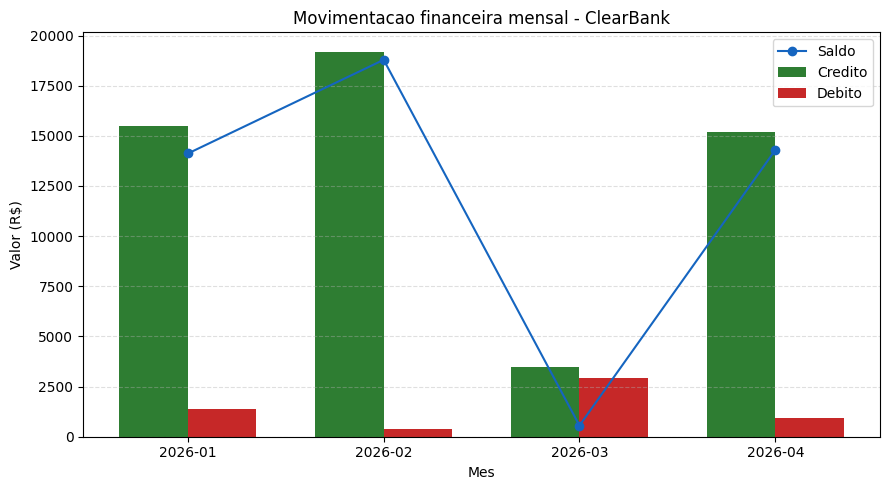

Grafico salvo em 'grafico.png'.


In [8]:
import matplotlib.pyplot as plt

meses = list(relatorio["resumo_mensal"].keys())
creditos = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
debitos = [relatorio["resumo_mensal"][m]["total_debito"] for m in meses]
saldos = [relatorio["resumo_mensal"][m]["saldo"] for m in meses]

x = range(len(meses))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - largura / 2 for i in x], creditos, largura, label="Credito", color="#2e7d32")
ax.bar([i + largura / 2 for i in x], debitos, largura, label="Debito", color="#c62828")
ax.plot(list(x), saldos, marker="o", color="#1565c0", label="Saldo")

ax.set_title("Movimentacao financeira mensal - ClearBank")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor (R$)")
ax.set_xticks(list(x))
ax.set_xticklabels(meses)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()

fig.savefig("grafico.png", dpi=120)
plt.show()
print("Grafico salvo em 'grafico.png'.")

## 10. (Opcional - RO1) Comparacao com pandas

A versao em pandas esta no arquivo `analise_pandas.py`. A celula abaixo
roda essa versao e confirma que os valores batem com a solucao nativa.


In [9]:
import analise_pandas as ap

df = ap.carregar_dados(ARQUIVO_CSV)
resumo_pd = ap.gerar_resumo_mensal(df)

print("Validacao: nativa x pandas")
print(f"Transacoes validas -> nativa: {relatorio['total_transacoes_validas']} | pandas: {len(df)}")
print()

todos_iguais = True
for mes, b in relatorio["resumo_mensal"].items():
    linha = resumo_pd.loc[mes]
    iguais = (
        round(b["total_credito"], 2) == round(float(linha["total_credito"]), 2)
        and round(b["total_debito"], 2) == round(float(linha["total_debito"]), 2)
        and round(b["saldo"], 2) == round(float(linha["saldo"]), 2)
    )
    todos_iguais = todos_iguais and iguais
    print(f"{mes}: saldo nativo {b['saldo']} | pandas {round(float(linha['saldo']), 2)} -> {'OK' if iguais else 'DIVERGENTE'}")

print()
print("Resultados identicos!" if todos_iguais else "Ha divergencias entre as versoes.")

Validacao: nativa x pandas
Transacoes validas -> nativa: 16 | pandas: 16

2026-01: saldo nativo 14119.5 | pandas 14119.5 -> OK
2026-02: saldo nativo 18790.1 | pandas 18790.1 -> OK
2026-03: saldo nativo 559.35 | pandas 559.35 -> OK
2026-04: saldo nativo 14290.0 | pandas 14290.0 -> OK

Resultados identicos!
